In [1]:
import pygimli as pg
import numpy as np
import matplotlib.pyplot as plt
from pygimli.physics import ert
import pygimli.meshtools as mt


(-250.0, 0.0)

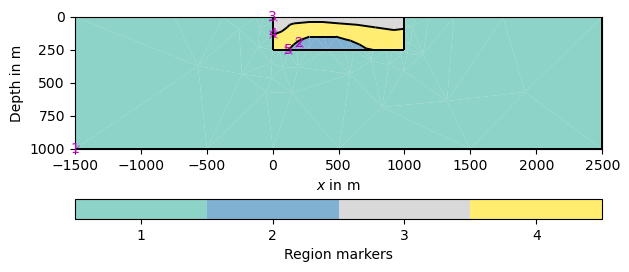

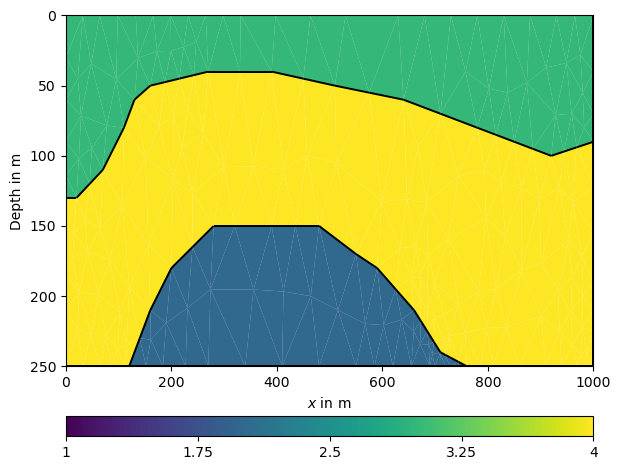

In [14]:
world=mt.createWorld(start=[-1500,0],end=[2500,-1000],worldMarker=1)

prec = 0.5


g0 = mt.createRectangle(start=[0,0], end=[1000,-250], marker=2)
g1_coords = np.round(np.loadtxt('shape_0.txt') / prec) * prec
g1 = mt.createPolygon(g1_coords, marker=3, isClosed=True)

g2_coords = np.round(np.loadtxt('shape_1.txt') / prec) * prec
g2 = mt.createPolygon(g2_coords, marker=4, isClosed=True)

g3_coords = np.round(np.loadtxt('shape_2.txt') / prec) * prec
g3 = mt.createPolygon(g3_coords, marker=5, isClosed=True)


geometry=world+g3+g2+g0+g1

pg.show(geometry,showMesh=True,quality=34)
mesh_cut = mt.createMesh(geometry, quality=34)
x_min,x_max= 0,1000
y_min,y_max= -250,0
ax,_=pg.show(mesh_cut,data=mesh_cut.cellMarkers(), showMesh=False, aspect='auto')    #cellMarkers gia ta xrwmata!
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

In [15]:
spacing=50
scheme1=ert.createData(
    elecs=np.linspace(start=0,stop=1000,num=len(np.arange(0,1001,spacing)))
    , schemeName='dd'
)
print(scheme1)

30/12/25 - 18:22:57 - pyGIMLi - INFO - Cache c:\Users\sider\.conda\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 9): C:\Users\sider\AppData\Roaming\pygimli\Cache\13677005616376912148


Data: Sensors: 21 data: 171, nonzero entries: ['a', 'b', 'k', 'm', 'n', 'valid']


30/12/25 - 18:26:36 - pyGIMLi - WARNING - parseMapToCellArray: cannot find marker 5 within mesh.


(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>,
 <matplotlib.colorbar.Colorbar at 0x2663585afd0>)

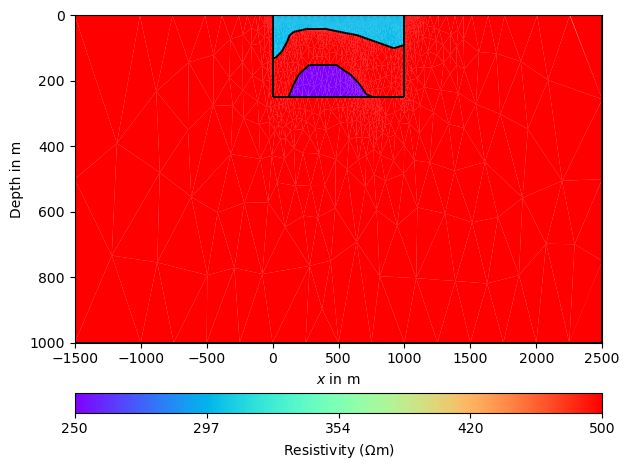

In [20]:
for p in scheme1.sensors():
    geometry.createNode(p)
    geometry.createNode(p-[0,0.1]) # φτιάχνω 2 nodes για το FTDT
mesh_fwr=mt.createMesh(geometry,quality=34)
rhomap=[[1,500],
        [2,250],
        [3,300],
        [4,500],
        [5,200]  
 
        ] # resistivity για κάθε marker
pg.show(mesh_fwr,data=rhomap,label=pg.unit('res'), cMap='rainbow',logScale=True,aspect='auto')

In [23]:
data1=ert.simulate(mesh_fwr,scheme=scheme1, res=rhomap, noiseLevel=5, noiseAbs=1e-6, seed=1337)

pg.info(np.linalg.norm(data1['err']),np.linalg.norm(data1['rhoa']))
pg.info('Simulated data: ',data1)
pg.info('The data contains : ',data1.dataMap().keys())
pg.info('Sim rhoa (min/max) : ' ,min(data1['rhoa']), max(data1['rhoa']))
pg.info('Selected data noise % (min/ma)x : ', min(data1['err'])*100, max(data1['err'])*100)


30/12/25 - 18:32:00 - pyGIMLi - WARNING - parseMapToCellArray: cannot find marker 5 within mesh.
30/12/25 - 18:32:00 - pyGIMLi - INFO - Data error estimate (min:max)  0.0500029283657378 : 0.053843184991760905
30/12/25 - 18:32:00 - pyGIMLi - INFO - 0.6593923645771893 4672.3200579870245
30/12/25 - 18:32:00 - pyGIMLi - INFO - Simulated data:  Data: Sensors: 21 data: 171, nonzero entries: ['a', 'b', 'err', 'i', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']
30/12/25 - 18:32:00 - pyGIMLi - INFO - The data contains :  ['a', 'b', 'err', 'i', 'ip', 'iperr', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']
30/12/25 - 18:32:00 - pyGIMLi - INFO - Sim rhoa (min/max) :  263.54004767420207 435.68177288785176
30/12/25 - 18:32:00 - pyGIMLi - INFO - Selected data noise % (min/ma)x :  5.00029283657378 5.38431849917609


relativeError set to a value > 0.5 .. assuming this is a percentage Error level dividing them by 100


30/12/25 - 18:32:03 - pyGIMLi - INFO - filtered rhoa minmax DD :  263.54004767420207 435.68177288785176


[[ 0  1  2  3]
 [ 1  2  3  4]
 [ 2  3  4  5]
 [ 3  4  5  6]
 [ 4  5  6  7]
 [ 5  6  7  8]
 [ 6  7  8  9]
 [ 7  8  9 10]
 [ 8  9 10 11]
 [ 9 10 11 12]
 [10 11 12 13]
 [11 12 13 14]
 [12 13 14 15]
 [13 14 15 16]
 [14 15 16 17]
 [15 16 17 18]
 [16 17 18 19]
 [17 18 19 20]
 [ 0  1  3  4]
 [ 1  2  4  5]
 [ 2  3  5  6]
 [ 3  4  6  7]
 [ 4  5  7  8]
 [ 5  6  8  9]
 [ 6  7  9 10]
 [ 7  8 10 11]
 [ 8  9 11 12]
 [ 9 10 12 13]
 [10 11 13 14]
 [11 12 14 15]
 [12 13 15 16]
 [13 14 16 17]
 [14 15 17 18]
 [15 16 18 19]
 [16 17 19 20]
 [ 0  1  4  5]
 [ 1  2  5  6]
 [ 2  3  6  7]
 [ 3  4  7  8]
 [ 4  5  8  9]
 [ 5  6  9 10]
 [ 6  7 10 11]
 [ 7  8 11 12]
 [ 8  9 12 13]
 [ 9 10 13 14]
 [10 11 14 15]
 [11 12 15 16]
 [12 13 16 17]
 [13 14 17 18]
 [14 15 18 19]
 [15 16 19 20]
 [ 0  1  5  6]
 [ 1  2  6  7]
 [ 2  3  7  8]
 [ 3  4  8  9]
 [ 4  5  9 10]
 [ 5  6 10 11]
 [ 6  7 11 12]
 [ 7  8 12 13]
 [ 8  9 13 14]
 [ 9 10 14 15]
 [10 11 15 16]
 [11 12 16 17]
 [12 13 17 18]
 [13 14 18 19]
 [14 15 19 20]
 [ 0  1  6

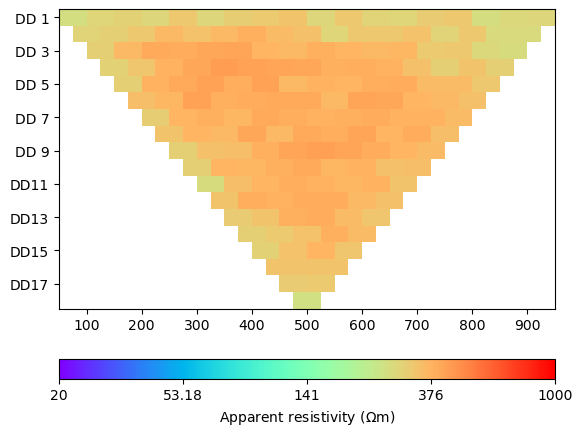

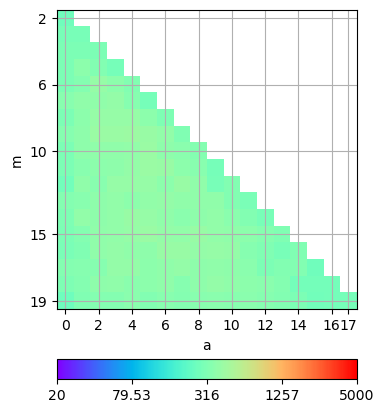

In [24]:
data1.remove(data1['rhoa']<0)
pg.info('filtered rhoa minmax DD : ', min(data1['rhoa']), max(data1['rhoa']))
#an thelw kanw save
data1.save('fwd_dd.dat')
ert.show(data1,cMap='rainbow',cMin=20,cMax=1000,logScale=True)   #pseudosection
pg.viewer.mpl.showDataContainerAsMatrix(data1,'a','m', 'rhoa',cMap='rainbow',cMin=20,cMax=5000,logScale=True,title='DD')

np.save("abmn_dd.npy", np.column_stack([data1['a'], data1['b'], data1['m'], data1['n']]))
np.save("res_all_dd.npy", np.column_stack([data1['rhoa']]))
abmn_data_dd = np.load("abmn_dd.npy")
print(abmn_data_dd)
print('------------------------------')
res_data_dd =np.load("res_all_dd.npy")
print(res_data_dd)

(<Axes: xlabel='a', ylabel='m'>,
 <matplotlib.colorbar.Colorbar at 0x26636d8f690>)

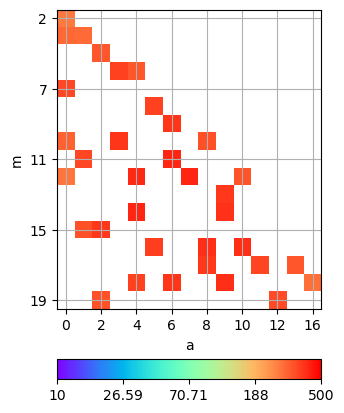

In [25]:
# twra ksekinaw na kovw metriseis apo to data gia na ftiaksw ta inversion data
no_mes1= np.array(data1['a']).shape[0]
ix1=np.random.choice(no_mes1, size=int(no_mes1*0.8), replace=False) # mark 8o% twn metrisewn

data1.markInvalid(ix1)
data1.removeInvalid() #ta afairw
pg.viewer.mpl.showDataContainerAsMatrix(data1,'a','m', 'rhoa',cMap='rainbow',cMin=10,cMax=500,logScale=True,title='DD')


In [26]:
mgr1=ert.ERTManager('fwd_dd.dat')
mesh1=mgr1.createMesh(quality=34,paraMaxCellSize=40 ,paraDepth=250,paraDx=20)
inv1 = mgr1.invert(mesh=mesh1,verbose=True)
# Check that chi2 is below a reasonable threshold
assert mgr1.inv.chi2() < 6000, f"DD chi2 too high: {mgr1.inv.chi2()}"

30/12/25 - 18:32:15 - pyGIMLi - INFO - Found 2 regions.
30/12/25 - 18:32:15 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
30/12/25 - 18:32:15 - pyGIMLi - INFO - Found 2 regions.
30/12/25 - 18:32:15 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
30/12/25 - 18:32:15 - pyGIMLi - INFO - Creating forward mesh from region infos.
30/12/25 - 18:32:16 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
30/12/25 - 18:32:16 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 31986 Cells: 63508 Boundaries: 47862
30/12/25 - 18:32:16 - pyGIMLi - INFO - Use median(data values)=360.315999348314
30/12/25 - 18:32:16 - pyGIMLi - INFO - Created startmodel from forward operator:13850, min/max=360.315999/360.315999
30/12/25 - 18:32:16 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x000002663554C1D0>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 264/436
min/max (error): 5%/5.38%
min/max (start model): 360/360
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =    5.61
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =    0.91 (dPhi = 80.08%) lam: 20.0


################################################################################
#                  Abort criterion reached: chi² <= 1 (0.91)                   #
################################################################################


(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>,
 <matplotlib.colorbar.Colorbar at 0x2667b0f8650>)

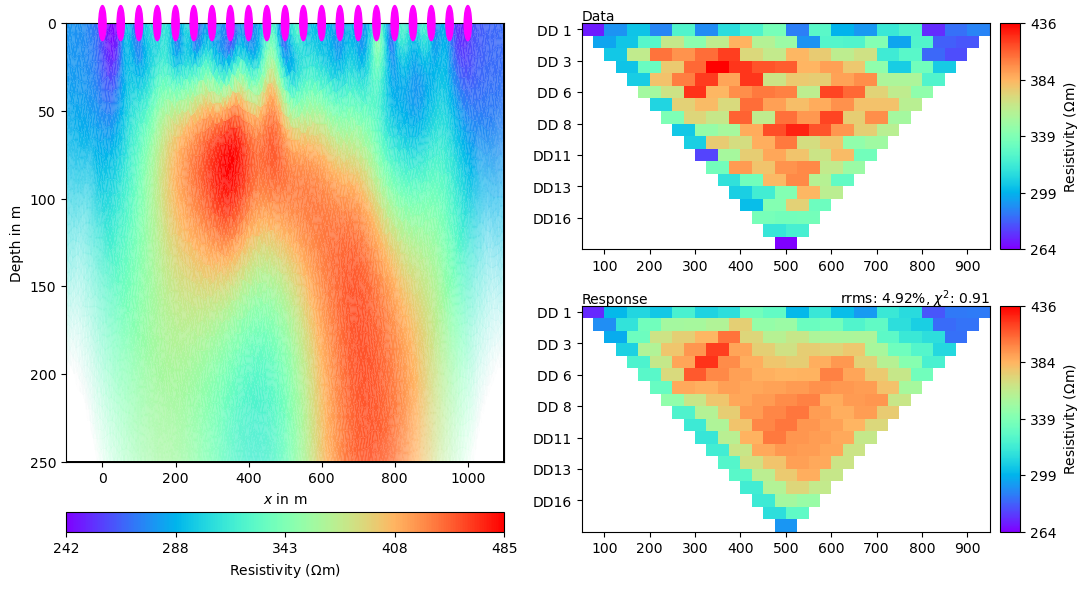

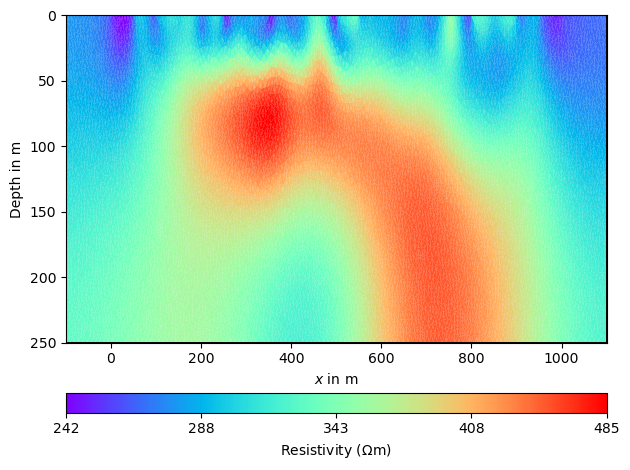

In [27]:
mgr1.showResultAndFit(vmin=1, vmax=1000, cMap='rainbow', logScale=True,aspect='auto')
meshPD1 = pg.Mesh(mgr1.paraDomain) # Save copy of para mesh for plotting later
pg.show(mgr1.paraDomain, inv1, label=pg.unit('res'), cMap='rainbow', logScale=True, vmin=1, vmax=1000,aspect='auto')
